In [1]:
import scanpy as sc
import anndata as ad
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, rgb2hex
import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
import numpy as np
from sklearn.metrics import jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42 # ADOBE AI 字帖

from matplotlib.font_manager import fontManager, FontProperties

fontManager.addfont('/data/work/Arial.ttf')

font = FontProperties(fname='/data/work/Arial.ttf')
font_name = font.get_name()
plt.rcParams['font.family'] = font_name

In [3]:
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/20250106/thalamus_latent_embeddings_all_spatial_pretrain/dmt_leiden_20250108_1.h5ad')
adata

AnnData object with n_obs × n_vars = 3279854 × 33347
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'slice_code', 'sub_region', 'dmt_leiden', 'annotation_1230', 'dmt_leiden_merge'
    uns: 'dmt_leiden_colors', 'dmt_leiden_merge_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [4]:
names = [
 '14_A03591A1C3_WT202403310045.h5ad',
 '16_A03592A4C6_WT202403310044.h5ad',
 '18_B03602C4D6_WT202405020031.h5ad',
 '20_B03606F3G5_WT202405020032.h5ad',
 '22_B03606C4E6_WT202403310050.h5ad',
 '23_B03609A4D6_WT202404150263.h5ad',
 '27_B03610C1E3_WT202403310051.h5ad',
 '31_B03619A1D3_WT202403310052.h5ad',
 '35_B03619E4G6_WT202403310053.h5ad',
 '39_A03589A1D4_WT202403310046.h5ad',
 '43_A03590E1G4_WT202403310064.h5ad',
 '47_A03593C1F3_WT202403310068.h5ad',
 '51_B03605C2E5_WT202406020126.h5ad',
 '55_B03613E3G6_WT202403310069.h5ad',
 '59_B03612E4G6_WT202403310059.h5ad',
 '63_B03606C1E3_WT202403310061.h5ad',
 '67_A03595A1D3_WT202403310062.h5ad',
 '71_A03595A4D6_WT202403310063.h5ad',
 '75_D03468D1E3_WT202403310066.h5ad',
 '80_D03473D4E6_WT202403310070.h5ad',
 '84_B03423D1E3_WT202403310065.h5ad',
 '89_D03466A1C3_WT202403310058.h5ad',
 '99_D03470D1E3_WT202404290071.h5ad',
 '104_B03615F3G5_WT202405020035.h5ad',
 '105_D03468A4C6_WT202403310067.h5ad',
 'A03988A1C2_WT202407161208.h5ad',
 # 'A03591D4E5_WT2024071215074.h5ad',
 'A03590A3D6_WT202407192652.h5ad',
 'A03994F1G2_WT2024071215067.h5ad',
    'A03587A5C6_WT2024071215080.h5ad', # GW10
 'B03607C4E6_WT2024071214941.h5ad', # GW12
    'B03618D3F6_WT202407152793.h5ad', # GW16
]

In [5]:
dic = {'0': 'T7_SST_LHX_SIX3',
 '1': 'T9_CRH',
 '10': 'T6_CLSTN2',
 '11': 'T4_COL4A1_vessel',
 '12': 'T3_BMP4_IGFBP5',
 '13': 'T7_SST_LHX_SIX3',
 '14': 'T0_PCP4_VGF',
 '15': 'T9_CRH',
 '16': 'T3_BMP4_IGFBP5',
 '17': 'T3_BMP4_IGFBP5',
 '18': 'T2_PRSS12',
 '19': 'T9_CRH',
 '2': 'T9_CRH',
 '20': 'T1_NTS_CALB1',
 '21': 'T1_NTS_CALB1',
 '22': 'T1_NTS_CALB1',
 '23': 'T10_HBZ',
 '24': 'T1_NTS_CALB1',
 '25': 'T1_NTS_CALB1',
 '26': 'T2_PRSS12',
 '27': 'T9_CRH',
 '28': 'T2_PRSS12',
 '29': 'T5_AQP4_gial_region',
 '3': 'T10_HBZ',
 '30': 'T8_CBLN4_CBLN1',
 '31': 'T7_SST_LHX_SIX3',
 '32': 'T9_CRH',
 '33': 'T1_NTS_CALB1',
 '34': 'T7_SST_LHX_SIX3',
 '35': 'T10_HBZ',
 '36': 'T8_CBLN4_CBLN1',
 '37': 'T9_CRH',
 '38': 'T3_BMP4_IGFBP5',
 '39': 'T1_NTS_CALB1',
 '4': 'T2_PRSS12',
 '40': 'T9_CRH',
 '41': 'T6_CLSTN2',
 '42': 'T10_HBZ',
 '5': 'T7_SST_LHX_SIX3',
 '6': 'T7_SST_LHX_SIX3',
 '7': 'T9_CRH',
 '8': 'T2_PRSS12',
 '9': 'T1_NTS_CALB1'}

adata.obs['dmt_leiden_annotation_0115'] = [dic[i] for i in adata.obs['dmt_leiden']]
colormap = {'T2_PRSS12': '#31d6d3',
 'T6_CLSTN2': '#6b0c4d',
 'T3_BMP4_IGFBP5': '#e94a1d',
 'T4_COL4A1_vessel': '#cf58e5',
 'T10_HBZ': '#39d789',
 'T7_SST_LHX_SIX3': '#4e7c26',
 'T8_CBLN4_CBLN1': '#eaccd8',
 'T1_NTS_CALB1': '#9114fb',
 'T9_CRH': '#79f4ec',
 'T0_PCP4_VGF': '#b3fcdd',
 'T5_AQP4_gial_region': '#455edf'}

In [5]:
adatas = []
for i in set(adata.obs['slice_code']):
    temp = adata[adata.obs['slice_code'] == i].copy()
    sc.pp.normalize_total(temp)
    sc.pp.log1p(temp)
    sc.pp.scale(temp, zero_center=False, max_value=10)
    adatas.append(temp)
adata = ad.concat(adatas)

In [6]:
adata.obs_names_make_unique()

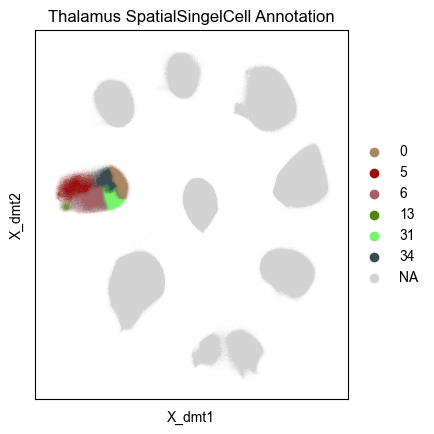

In [13]:
plot = sc.pl.embedding(adata, basis = 'X_dmt',color = 'dmt_leiden', groups = ['0', '13', '31', '34', '5', '6'], palette= temp_color_dic,show = False, title = 'Thalamus SpatialSingelCell Annotation'); 
plot.set_aspect('equal')
plt.show()
# plt.savefig(f'/data/work/05.cluster/FuseMap/0117/tha_spatial/dmt_plot.png', bbox_inches = 'tight', dpi = 600)

In [11]:
import numpy as np
from matplotlib.colors import ListedColormap, rgb2hex
dmt_leiden_anno = list(set(adata.obs['dmt_leiden']))
number_of_colors = len(dmt_leiden_anno)
colors = np.random.rand(number_of_colors, 3)
custom_cmap = ListedColormap(colors)
hex_colors = [rgb2hex(color) for color in custom_cmap.colors]
temp_color_dic = {dmt_leiden_anno[i]:hex_colors[i] for i in range(number_of_colors) }
temp_color_dic

{'15': '#22f6ce',
 '4': '#daab7c',
 '20': '#a6e1b6',
 '23': '#ccaf30',
 '36': '#fc45f7',
 '25': '#324bad',
 '42': '#0e183f',
 '1': '#d2a5ca',
 '7': '#de9559',
 '41': '#f866d7',
 '2': '#f4046e',
 '5': '#9e0b0b',
 '6': '#a56065',
 '33': '#c64a56',
 '19': '#2cc858',
 '14': '#60fbea',
 '31': '#77f56d',
 '32': '#e3e749',
 '17': '#35786f',
 '40': '#b163b9',
 '29': '#908910',
 '3': '#22a8d6',
 '30': '#58ff92',
 '38': '#5eb205',
 '18': '#cea0c3',
 '21': '#fcf316',
 '26': '#77f26f',
 '10': '#090467',
 '9': '#3fcc55',
 '16': '#e5a366',
 '13': '#508409',
 '37': '#3c38f2',
 '28': '#5bba43',
 '22': '#e2c593',
 '0': '#a98761',
 '27': '#d4537b',
 '11': '#7dc542',
 '12': '#04e474',
 '8': '#78fc86',
 '39': '#cf70e0',
 '34': '#3b4b50',
 '24': '#fafa24',
 '35': '#84cf44'}

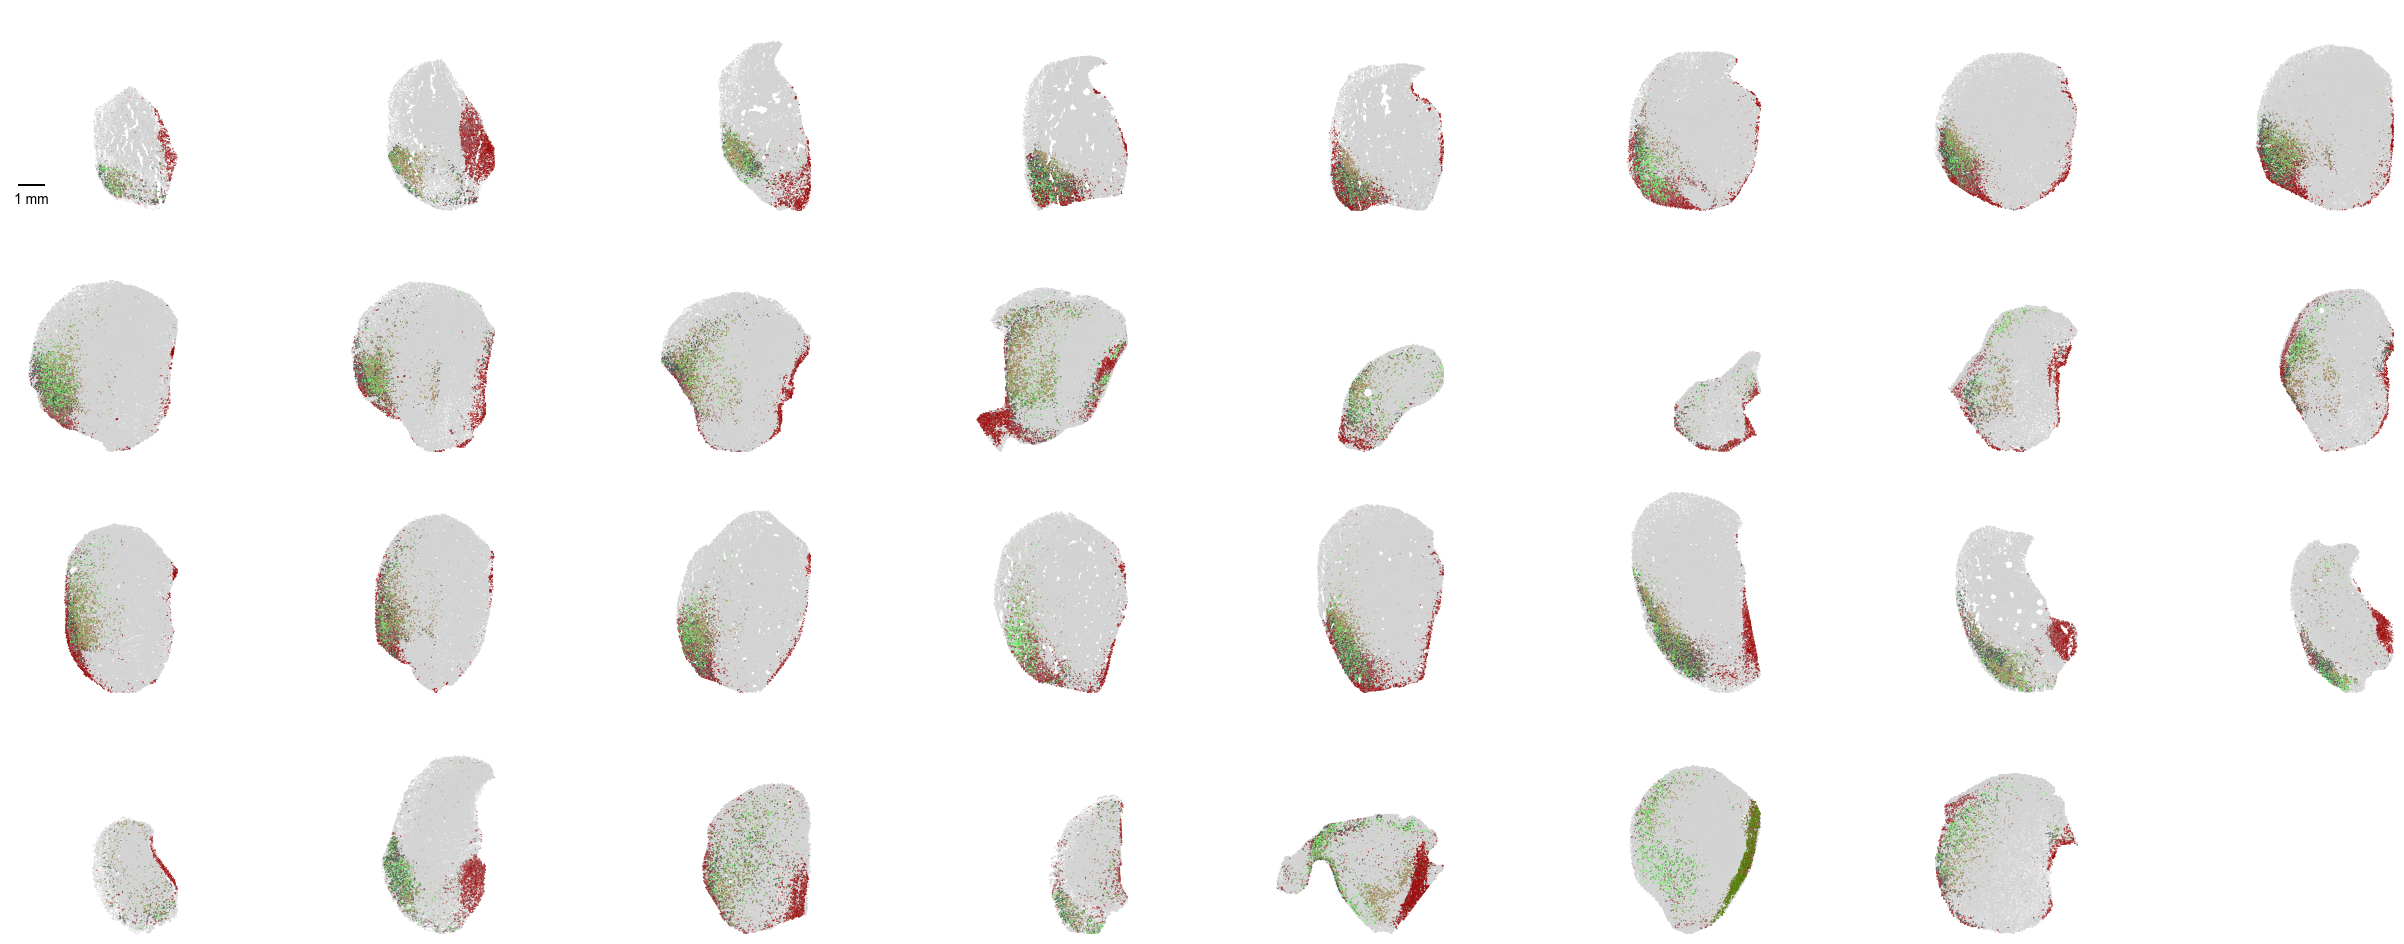

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

fig = plt.figure(figsize=(32, 12))
gs = GridSpec(4, 8, figure=fig)

x_min, x_max, y_min, y_max = float('inf'), float('-inf'), float('inf'), float('-inf')
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]
    
    x_min = min(x_min, adata_temp.obsm['align_spatial_2d'][:, 0].min())
    x_max = max(x_max, adata_temp.obsm['align_spatial_2d'][:, 0].max())
    y_min = min(y_min, adata_temp.obsm['align_spatial_2d'][:, 1].min())
    y_max = max(y_max, adata_temp.obsm['align_spatial_2d'][:, 1].max())

count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]
    row = (count // 8) + 1  
    col = count % 8      
    ax = fig.add_subplot(gs[row-1, col])
    
    sc.pl.embedding(
        adata_temp, basis="align_spatial_2d", color='dmt_leiden',groups = ['0', '13', '31', '34', '5', '6'],
        show=False, s=1, title='', legend_loc=None, ax=ax, palette=temp_color_dic
    )
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    ax.axis('off')
    ax.set_aspect('equal')
    # scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
    # ax.add_artist(scalebar)
    if count == 0:
        scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
        ax.add_artist(scalebar)
    count += 1
plt.show()

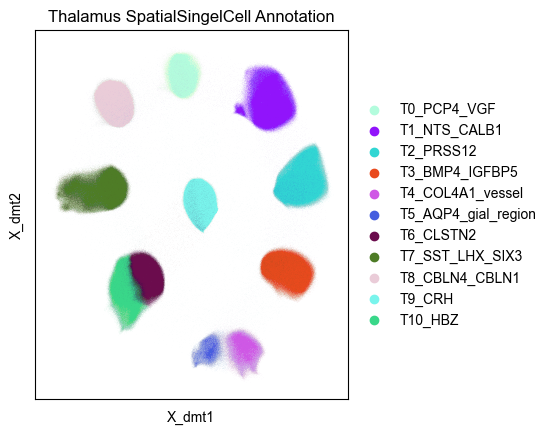

In [20]:
plot = sc.pl.embedding(adata, basis = 'X_dmt',color = 'dmt_leiden_annotation_0115', palette = colormap, show = False, title = 'Thalamus SpatialSingelCell Annotation'); 
plot.set_aspect('equal')
plt.savefig(f'/data/work/05.cluster/FuseMap/0117/tha_spatial/dmt_plot.png', bbox_inches = 'tight', dpi = 600)

In [21]:
var = ['PCP4', 'VGF', 'KCNJ5',
                        'CD247', 'PENK', 'NTS', 'CALB1',
                        'PRSS12',
                        'BMP4','IGFBP5',
                        'COL4A1', 'FN1',
                        'APOE', 'AQP4',
                        'CLSTN2','KCNK17',
                        'SST', 'LHX1', 'SIX3',
                        'CBLN4','CBLN1',
                        'EGR1', 'CRH',
                        'HBZ']

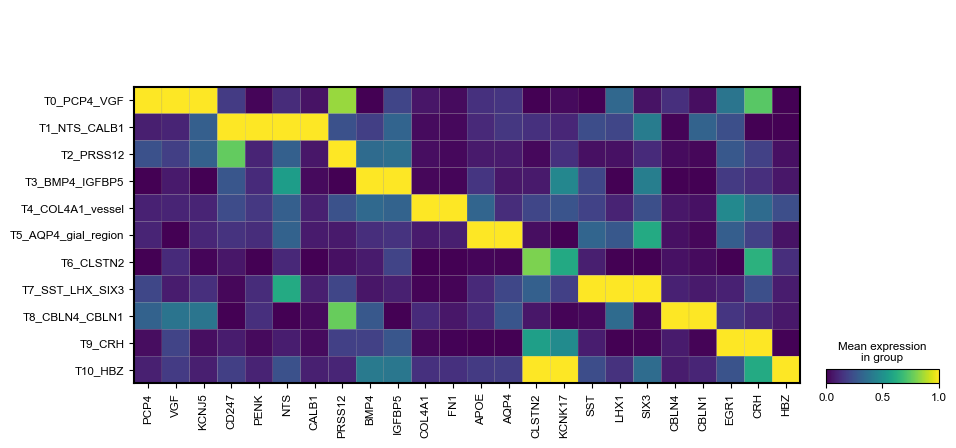

In [22]:
sc.pl.matrixplot(adata, 
                 var, 
                 'dmt_leiden_annotation_0115', 
                 standard_scale = 'var',
                 # dendrogram = True,
                 show = False
                )
plt.savefig(f'/data/work/05.cluster/FuseMap/0117/tha_spatial/matrixplot.pdf', bbox_inches = 'tight', dpi = 600)
# plt.close()

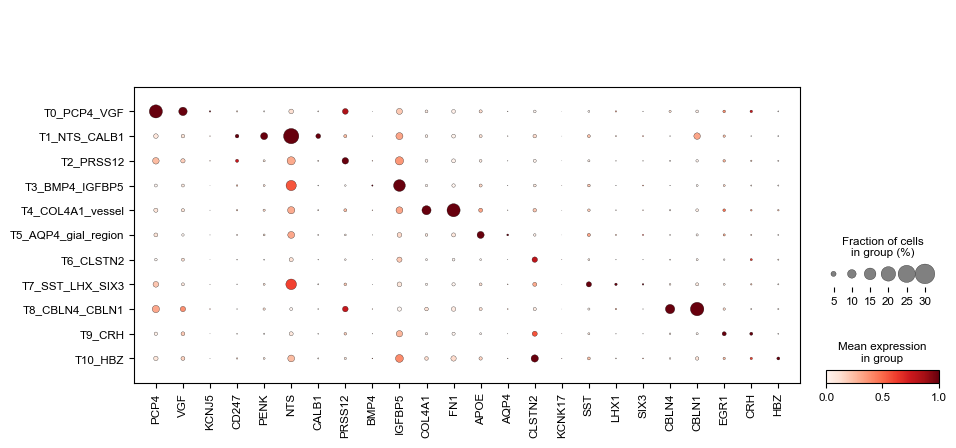

In [23]:
sc.pl.dotplot(adata, 
                 var, 
                 'dmt_leiden_annotation_0115', 
                 standard_scale = 'var',
              show = False
                )
plt.savefig(f'/data/work/05.cluster/FuseMap/0117/tha_spatial/dotplot.pdf', bbox_inches = 'tight', dpi = 600)
# plt.close()

In [24]:
len(names)

31

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# 创建画布和网格布局
fig = plt.figure(figsize=(32, 12))
gs = GridSpec(4, 8, figure=fig)

# 计算全局坐标范围
x_min, x_max, y_min, y_max = float('inf'), float('-inf'), float('inf'), float('-inf')
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]
    
    x_min = min(x_min, adata_temp.obsm['align_spatial_2d'][:, 0].min())
    x_max = max(x_max, adata_temp.obsm['align_spatial_2d'][:, 0].max())
    y_min = min(y_min, adata_temp.obsm['align_spatial_2d'][:, 1].min())
    y_max = max(y_max, adata_temp.obsm['align_spatial_2d'][:, 1].max())

# 绘制子图
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]
    row = (count // 8) + 1  
    col = count % 8      
    # count +=1
    ax = fig.add_subplot(gs[row-1, col])
    
    # 绘制嵌入图
    sc.pl.embedding(
        adata_temp, basis="align_spatial_2d", color='dmt_leiden_annotation_0115',
        show=False, s=1, title='', legend_loc=None, ax=ax, palette=colormap
    )
    
    # 设置统一的坐标轴范围
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # 关闭坐标轴并设置等比例缩放
    ax.axis('off')
    ax.set_aspect('equal')
    # scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
    # ax.add_artist(scalebar)
    if count == 0:
        scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
        ax.add_artist(scalebar)
    count += 1
plt.savefig(f'/data/work/05.cluster/FuseMap/0117/tha_spatial/spatial_plot_all.png', bbox_inches = 'tight', dpi = 600)
plt.close()
# plt.show()

In [8]:
x_min, x_max, y_min, y_max = float('inf'), float('-inf'), float('inf'), float('-inf')
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]
    x_min = min(x_min, adata_temp.obsm['align_spatial_2d'][:, 0].min())
    x_max = max(x_max, adata_temp.obsm['align_spatial_2d'][:, 0].max())
    y_min = min(y_min, adata_temp.obsm['align_spatial_2d'][:, 1].min())
    y_max = max(y_max, adata_temp.obsm['align_spatial_2d'][:, 1].max())
for i in set(adata.obs['dmt_leiden_annotation_0115']):
    fig = plt.figure(figsize=(32, 12))
    gs = GridSpec(4, 8, figure=fig)
    count = 0
    for name in names:
        adata_temp = adata[adata.obs['slice_code'] == name].copy()
        adata_temp.obsm['align_spatial_2d'] = adata_temp.obsm['align_spatial_2d'] - adata_temp.obsm['align_spatial_2d'].max(axis = 0)
        adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

        row = (count // 8) + 1
        col = count % 8  
        ax = fig.add_subplot(gs[row-1, col])
        sc.pl.embedding(
            adata_temp, basis="align_spatial_2d", color='dmt_leiden_annotation_0115',groups = i,
            show=False, s=1, title='', legend_loc=None, ax=ax, palette=colormap
        )
        
        # 设置统一的坐标轴范围
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        
        ax.axis('off')
        ax.set_aspect('equal')
        
        if count == 0:
            scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,)
            ax.add_artist(scalebar)
        count+=1

    plt.savefig(f'/data/work/05.cluster/FuseMap/20250117/tha_spatial/spatial_plot_{i}.png', bbox_inches = 'tight', dpi = 600)
    plt.close()